# Feature Extraction & Price Prediction for Mobile Phones

**Project:** Predicting mobile phone prices from device specifications, and identifying which features most influence price.

**Dataset:** `Processed_Flipdata.xlsx` — 541 mobile phone listings scraped from Flipkart, with columns for model, colour, memory, RAM, battery, rear/front camera, AI lens, mobile height, processor, and price.

**Workflow:**
1. Data Exploration
2. Feature Engineering (cleanup needed before EDA)
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Feature Extraction (correlation-based)
6. Model Building (Linear Regression, Decision Tree, Random Forest, Gradient Boosting)
7. Model Evaluation (MAE, RMSE, R²)
8. Feature Importance Analysis
9. Recommendations & Conclusion


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)


## 1. Data Exploration

Load the dataset and get a first look at its structure, data types, and value ranges.

In [2]:
## load Dataset
df = pd.read_excel(r'D:\nexthikes solutions internship\Project4 Feature Engineering ML\Processed_Flipdata.xlsx')
print("Shape:", df.shape)
df.head()

Shape: (541, 12)


,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    str    
 2   Colour         541 non-null    str    
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    str    
 7   Front Camera   541 non-null    str    
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    str    
 11  Prize          541 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 50.8 KB


In [3]:
df.columns

Index(['Unnamed: 0', 'Model', 'Colour', 'Memory', 'RAM', 'Battery_',
       'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_',
       'Prize'],
      dtype='object')

In [4]:
#Statistical Summary
df.describe()

,Unnamed: 0,Memory,RAM,Battery_,AI Lens,Mobile Height,Prize
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,289.711645,110.550832,5.397412,4871.587800,0.062847,16.431201,16228.375231
std,182.359185,60.600694,1.984923,780.148862,0.242911,2.523553,10793.588322
min,0.000000,16.000000,2.000000,800.000000,0.000000,4.500000,920.000000
25%,135.000000,64.000000,4.000000,5000.000000,0.000000,16.510000,9290.000000
50%,273.000000,128.000000,6.000000,5000.000000,0.000000,16.710000,13499.000000
75%,434.000000,128.000000,8.000000,5000.000000,0.000000,16.940000,19280.000000
max,642.000000,256.000000,8.000000,7000.000000,1.000000,41.940000,80999.000000


In [5]:
#Categorical Summary
df.describe(include='object')

,Model,Colour,Rear Camera,Front Camera,Processor_
count,541,541,541,541,541
unique,187,275,14,13,123
top,vivo Y16,Yellow,50MP,16MP,Qualcomm Snapdragon 680
freq,9,12,260,164,33


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,541.0,NaN,NaN,NaN,289.711645,182.359185,0.0,135.0,273.0,434.0,642.0
Model,541,187,realme C55,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Colour,541,275,Yellow,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Memory,541.0,NaN,NaN,NaN,110.550832,60.600694,16.0,64.0,128.0,128.0,256.0
RAM,541.0,NaN,NaN,NaN,5.397412,1.984923,2.0,4.0,6.0,8.0,8.0
Battery_,541.0,NaN,NaN,NaN,4871.5878,780.148862,800.0,5000.0,5000.0,5000.0,7000.0
Rear Camera,541,14,50MP,260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Front Camera,541,13,16MP,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AI Lens,541.0,NaN,NaN,NaN,0.062847,0.242911,0.0,0.0,0.0,0.0,1.0
Mobile Height,541.0,NaN,NaN,NaN,16.431201,2.523553,4.5,16.51,16.71,16.94,41.94


**Initial observations**

- 541 rows, 12 columns (including an unnamed index column).
- `Rear Camera` and `Front Camera` are stored as text (e.g. `"50MP"`), not numeric.
- `Model`, `Colour`, and `Processor_` are free-text categorical fields with very high cardinality.
- `Prize` is the target variable (price in ₹).
- `AI Lens` is already a binary 0/1 flag.

In [13]:
# Drop the redundant index column
df = df.drop(columns=["Unnamed: 0"])

# Check for missing values
df.isnull().sum()

Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

No missing values in any column, so no imputation is required.

In [8]:
# Check the number of duplicate records
df.duplicated().sum()
# no duplicate records found

np.int64(0)

In [14]:
# Check inconsistency
cat_cols = df.select_dtypes(include='object').columns
cat_cols
#There is no inconsistenty found in Categorical Cols

Index(['Model', 'Colour', 'Rear Camera', 'Front Camera', 'Processor_'], dtype='object')

In [15]:
df.nunique()

Model            187
Colour           275
Memory             5
RAM                5
Battery_          37
Rear Camera       14
Front Camera      13
AI Lens            2
Mobile Height     38
Processor_       123
Prize            158
dtype: int64

### Key Observations:
- ✓ **No Missing Values**: Dataset is complete
- ✓ **No Duplicate Values**: Dataset is complete
- ✓ **541 Mobile Phones** with 11 features
- ✓ **Price Range**: ₹920 - ₹80,999
- ✓ **Feature Types**:
  - Numerical: Memory (GB), RAM (GB), Battery (mAh), Mobile Height
  - Categorical: Model, Colour, Rear Camera, Front Camera, Processor
  - Binary: AI Lens (0/1)
- ✓ **Target Variable**: Prize (Price)

## 2. Feature Engineering (Cleanup Needed Before Exploring the Data)

Three columns are unusable in their raw form and need converting before any meaningful exploration or plotting can be done:

- **`Rear Camera` / `Front Camera`** — text like `"50MP"` needs to become a numeric megapixel value.
- **`Model`** — 187 unique values, mostly one-off. We extract the **Brand** (first word of the model name) as a lower-cardinality, more generalizable categorical feature. Brand names are also inconsistently capitalized/typo'd in the raw data (`"micromax1"`, `"I Kall"`, mixed case), so we normalize them.
- **`Processor_`** — 123 unique raw strings referring to the same handful of chipset families (e.g. `"G37"`, `"Mediatek Helio G37"`, `"Helio G85"`). We extract a **Processor Family** (Snapdragon, Dimensity, Helio, Unisoc, Exynos, Apple Bionic, Google Tensor, Other).

The rest of the preprocessing (outlier handling, dropping `Colour`, encoding, a height correction) happens later in Section 4, after we've explored the data.

In [16]:
def get_brand(model):
    m = model.strip()
    if m.upper().startswith("I KALL"):
        return "IKALL"
    if m.upper().startswith("MICROMAX"):
        return "MICROMAX"
    return m.split()[0].upper()

df["Brand"] = df["Model"].apply(get_brand)
df["Brand"].value_counts()

Brand
REALME      98
REDMI       75
INFINIX     65
VIVO        62
POCO        60
SAMSUNG     55
MOTOROLA    46
TECNO       17
OPPO        16
MICROMAX    14
GOOGLE       9
ONEPLUS      5
APPLE        5
ITEL         3
NOKIA        3
NOTHING      2
IKALL        2
IQOO         2
LAVA         2
Name: count, dtype: int64

In [17]:
# Convert camera specs from text ("50MP") to numeric megapixels
df["Rear_Camera_MP"] = df["Rear Camera"].str.replace("MP", "", regex=False).astype(float)
df["Front_Camera_MP"] = df["Front Camera"].str.replace("MP", "", regex=False).astype(float)

df[["Rear_Camera_MP", "Front_Camera_MP"]].describe()

,Rear_Camera_MP,Front_Camera_MP
count,541.000000,541.000000
mean,46.110906,11.992606
std,31.260416,9.053746
min,0.000000,0.000000
25%,13.000000,5.000000
50%,50.000000,8.000000
75%,50.000000,16.000000
max,200.000000,60.000000


In [24]:
def get_processor_family(proc):
    p = proc.lower()
    if "snapdragon" in p:
        return "Snapdragon"
    if "dimensity" in p:
        return "Dimensity"
    if "helio" in p or (p.strip().startswith("g") and any(ch.isdigit() for ch in p)):
        return "Helio"
    if "unisoc" in p or "spreadtrum" in p or p.strip().startswith("t6"):
        return "Unisoc"
    if "exynos" in p:
        return "Exynos"
    if "bionic" in p or "apple" in p:
        return "Apple_Bionic"
    if "tensor" in p:
        return "Google_Tensor"
    return "Other"

df["Processor_Family"] = df["Processor_"].apply(get_processor_family)
df["Processor_Family"].value_counts()

Processor_Family
Helio            163
Snapdragon       130
Dimensity        109
Unisoc            61
Other             43
Exynos            30
Google_Tensor      5
Name: count, dtype: int64

## 3. Exploratory Data Analysis (EDA)

Now that camera specs, brand, and processor family are usable, explore the shape of each variable individually (univariate), then how pairs of variables relate to price (bivariate), and finally look across several variables together (multivariate).

### Summary:
**What we do:**
1. Visualize price distribution
2. Analyze relationships between features and price
3. Understand feature distributions and patterns
4. Calculate correlations with price

**Why it matters:**
- Identify price patterns and outliers
- Understand which features influence price
- Detect data anomalies before modeling

### 3.1 Univariate Analysis — Target Variable (Price)

In [18]:
num_cols = df.select_dtypes(include=['number']).columns

print(num_cols)

Index(['Memory', 'RAM', 'Battery_', 'AI Lens', 'Mobile Height', 'Prize',
       'Rear_Camera_MP', 'Front_Camera_MP'],
      dtype='object')


In [19]:
# Select numerical columns
num_cols = df.select_dtypes(include='number')

# Compute statistical measures
stats_summary = pd.DataFrame({
    'Mean': num_cols.mean(),
    'Median': num_cols.median(),
    'Std_Deviation': num_cols.std(),
    'Minimum': num_cols.min(),
    'Maximum': num_cols.max(),
    'Skewness': num_cols.skew(),
    'Kurtosis': num_cols.kurt()
})

# Display result
stats_summary

,Mean,Median,Std_Deviation,Minimum,Maximum,Skewness,Kurtosis
Memory,110.550832,128.00,60.600694,16.0,256.00,1.029704,0.855888
RAM,5.397412,6.00,1.984923,2.0,8.00,0.067617,-1.306301
Battery_,4871.587800,5000.00,780.148862,800.0,7000.00,-3.304250,14.752188
AI Lens,0.062847,0.00,0.242911,0.0,1.00,3.612638,11.092146
Mobile Height,16.431201,16.71,2.523553,4.5,41.94,1.171778,48.220112
Prize,16228.375231,13499.00,10793.588322,920.0,80999.00,2.425579,9.606035
Rear_Camera_MP,46.110906,50.00,31.260416,0.0,200.00,1.799491,7.227342
Front_Camera_MP,11.992606,8.00,9.053746,0.0,60.00,2.492864,8.756549


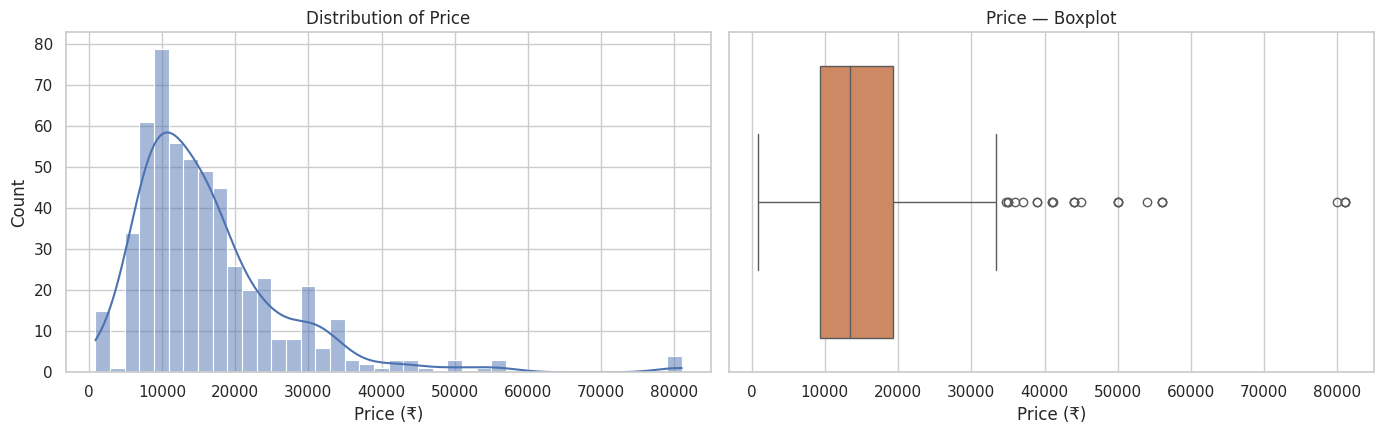

Skewness: 2.43
Kurtosis: 9.61


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(df["Prize"], bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Price")
axes[0].set_xlabel("Price (₹)")

sns.boxplot(x=df["Prize"], ax=axes[1], color="#DD8452")
axes[1].set_title("Price — Boxplot")
axes[1].set_xlabel("Price (₹)")
plt.tight_layout()
plt.show()

print("Skewness:", df["Prize"].skew().round(2))
print("Kurtosis:", df["Prize"].kurt().round(2))

Price is **right-skewed** (skew ≈ 1.7) — most phones cluster in the ₹5,000–₹20,000 budget/mid-range, with a long tail of flagship devices (iPhones, Galaxy S-series, Pixel) pulling the mean above the median. This confirms tree-based models (which don't assume normality or linear relationships) are a good fit alongside linear regression.

### 3.2 Univariate Analysis — Numeric Specifications

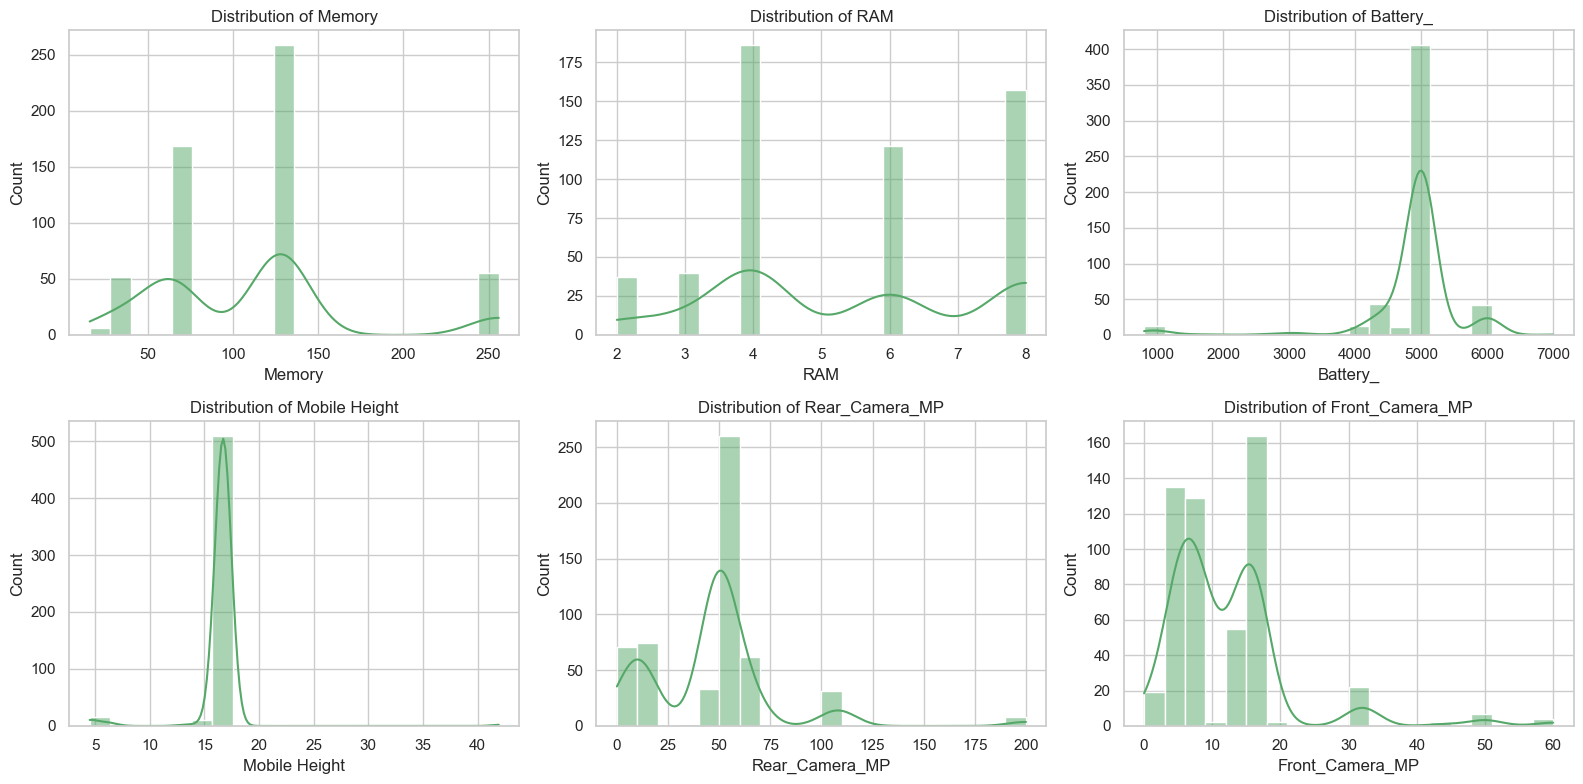

In [20]:
numeric_features = ["Memory", "RAM", "Battery_", "Mobile Height", "Rear_Camera_MP", "Front_Camera_MP"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_features):
    sns.histplot(df[col], bins=20, kde=True, ax=ax, color="#55A868")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

- **Memory (storage)** clusters heavily at common tiers — 32GB, 64GB, 128GB, 256GB — as expected for a categorical-like numeric spec.
- **RAM** shows similar step-wise clustering (2/4/6/8GB).
- **Battery** is heavily concentrated around 5,000mAh — the industry-standard capacity — with a small cluster of older/budget/basic phones below 2,000mAh.
- **Mobile Height** is tightly clustered ~16–17cm (typical smartphone screens), with a small group of very low values corresponding to basic/feature phones (`redmi min`, `micromax` keypad models).
- **Camera MPs** are multi-modal, reflecting distinct camera "tiers" manufacturers market at (5MP, 8MP, 13MP, 50MP, etc.) rather than a smooth range.

### 3.3 Univariate Analysis — Categorical Features

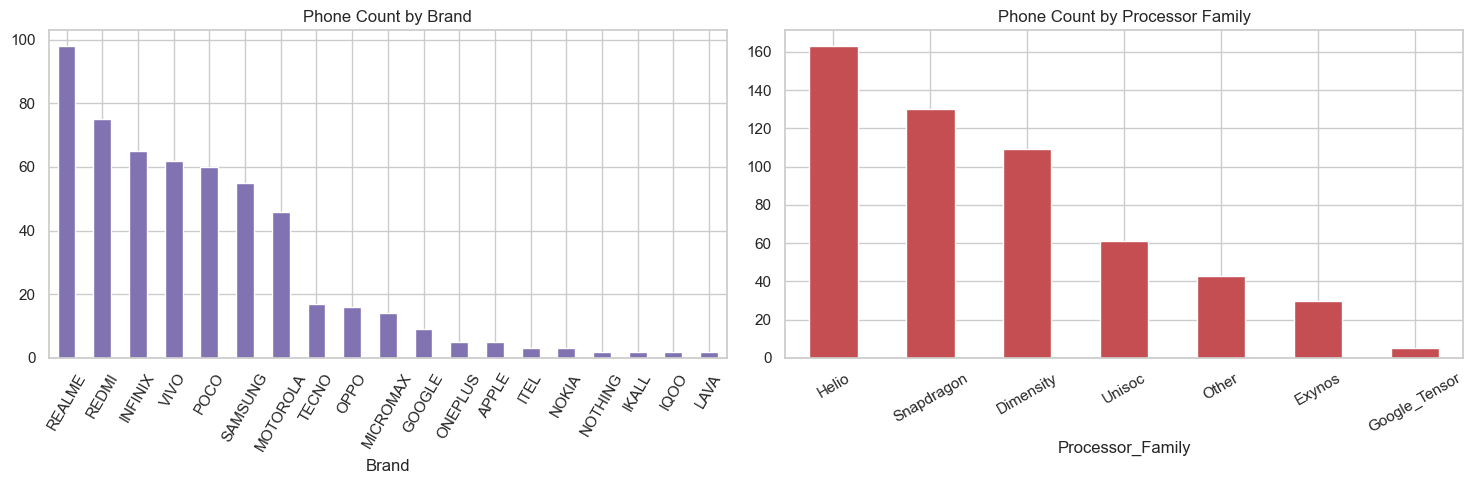

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Brand
df["Brand"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color="#8172B2"
)
axes[0].set_title("Phone Count by Brand")
axes[0].tick_params(axis="x", rotation=60)

# Processor Family (use the actual column name)
df["Processor_Family"].value_counts().plot(
    kind="bar",
    ax=axes[1],
    color="#C44E52"
)
axes[1].set_title("Phone Count by Processor Family")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [26]:
ai_lens_share = df["AI Lens"].value_counts(normalize=True) * 100
print("AI Lens presence (%):")
print(ai_lens_share.round(1))

AI Lens presence (%):
AI Lens
0    93.7
1     6.3
Name: proportion, dtype: float64


realme, REDMI, Infinix, vivo, and POCO dominate the listing count — this dataset skews toward budget/mid-range Android brands, with only a handful of Apple/Google/OnePlus flagships. Helio and Snapdragon are the most common processor families. Only about 6% of listed phones have an AI lens, making it a rare, premium-leaning feature rather than a mainstream one.

### 3.4 Bivariate Analysis — Specs vs Price

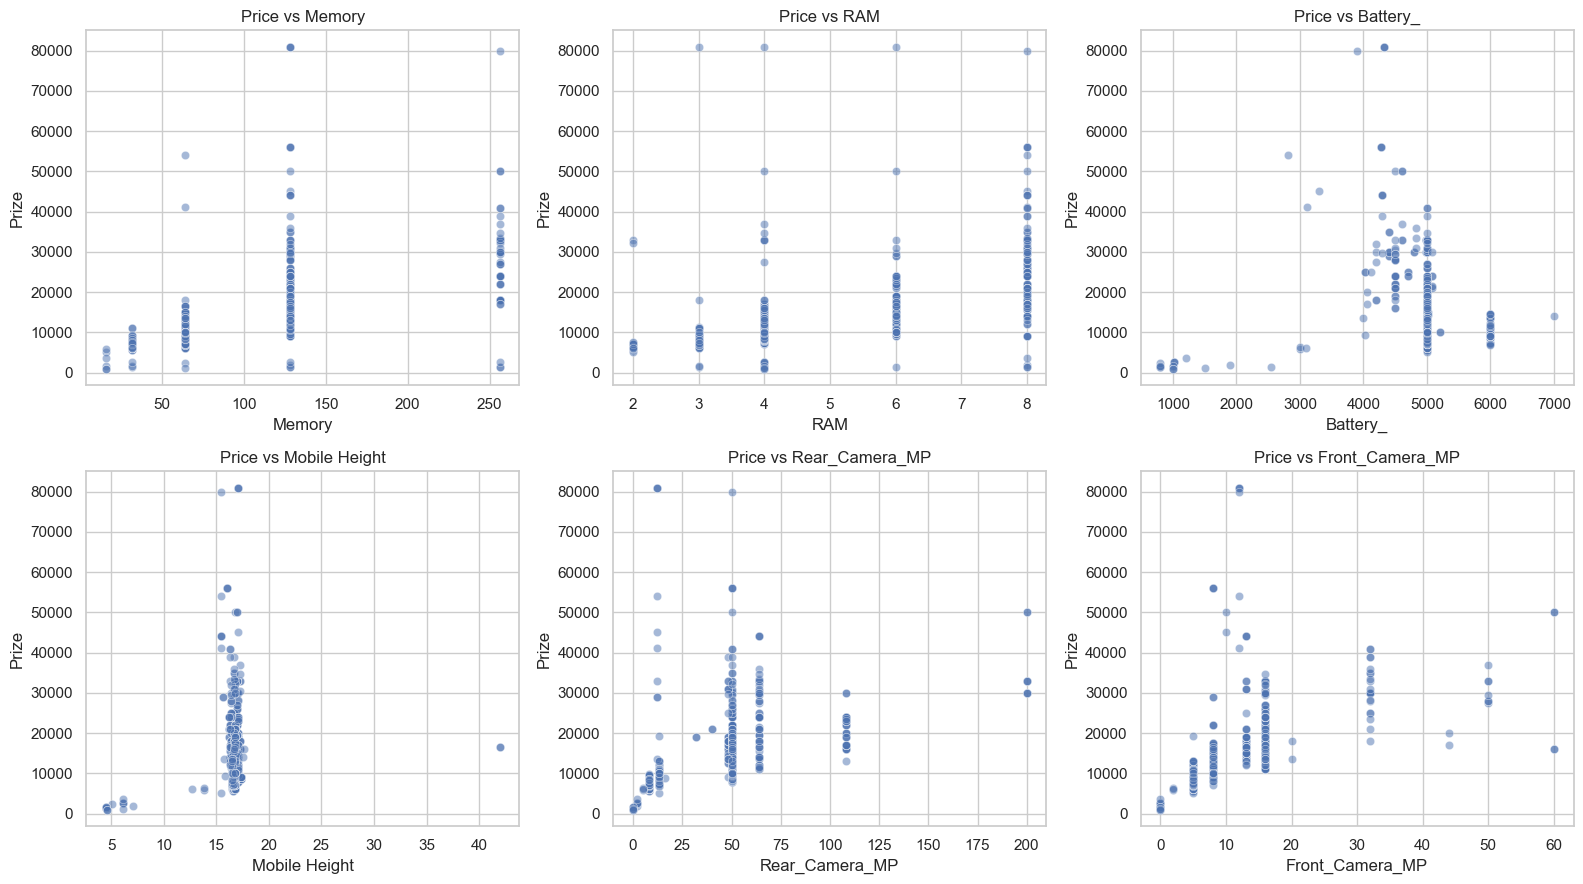

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), numeric_features):
    sns.scatterplot(data=df, x=col, y="Prize", alpha=0.5, ax=ax, color="#4C72B0")
    ax.set_title(f"Price vs {col}")
plt.tight_layout()
plt.show()

C:\Users\Ashu\AppData\Local\Temp\ipykernel_7912\2696919565.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="AI Lens", y="Prize", palette="Set2")


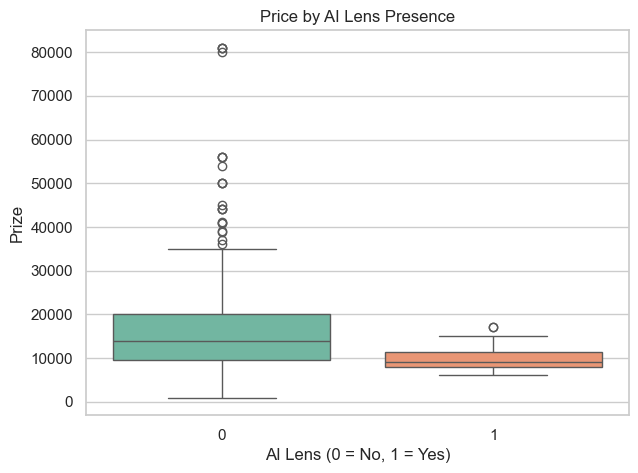

In [28]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="AI Lens", y="Prize", palette="Set2")
plt.title("Price by AI Lens Presence")
plt.xlabel("AI Lens (0 = No, 1 = Yes)")
plt.show()

- **Memory, RAM, and both camera specs** show a clear upward trend with price — higher specs, higher price, though with plenty of scatter (brand and other factors also matter).
- **Battery** shows almost no visible trend — most phones sit at 5,000mAh regardless of price tier, confirming the near-zero linear correlation found in Section 5.
- **Mobile Height** shows a weak, noisy relationship — a handful of basic phones at the low end pull down the low-price/low-height corner, but among normal smartphones there's little price signal.
- Phones **with an AI lens are priced noticeably higher on average** — consistent with AI lens being a premium/marketing feature bundled into higher-spec devices rather than a standalone driver.

### 3.5 Multivariate Analysis

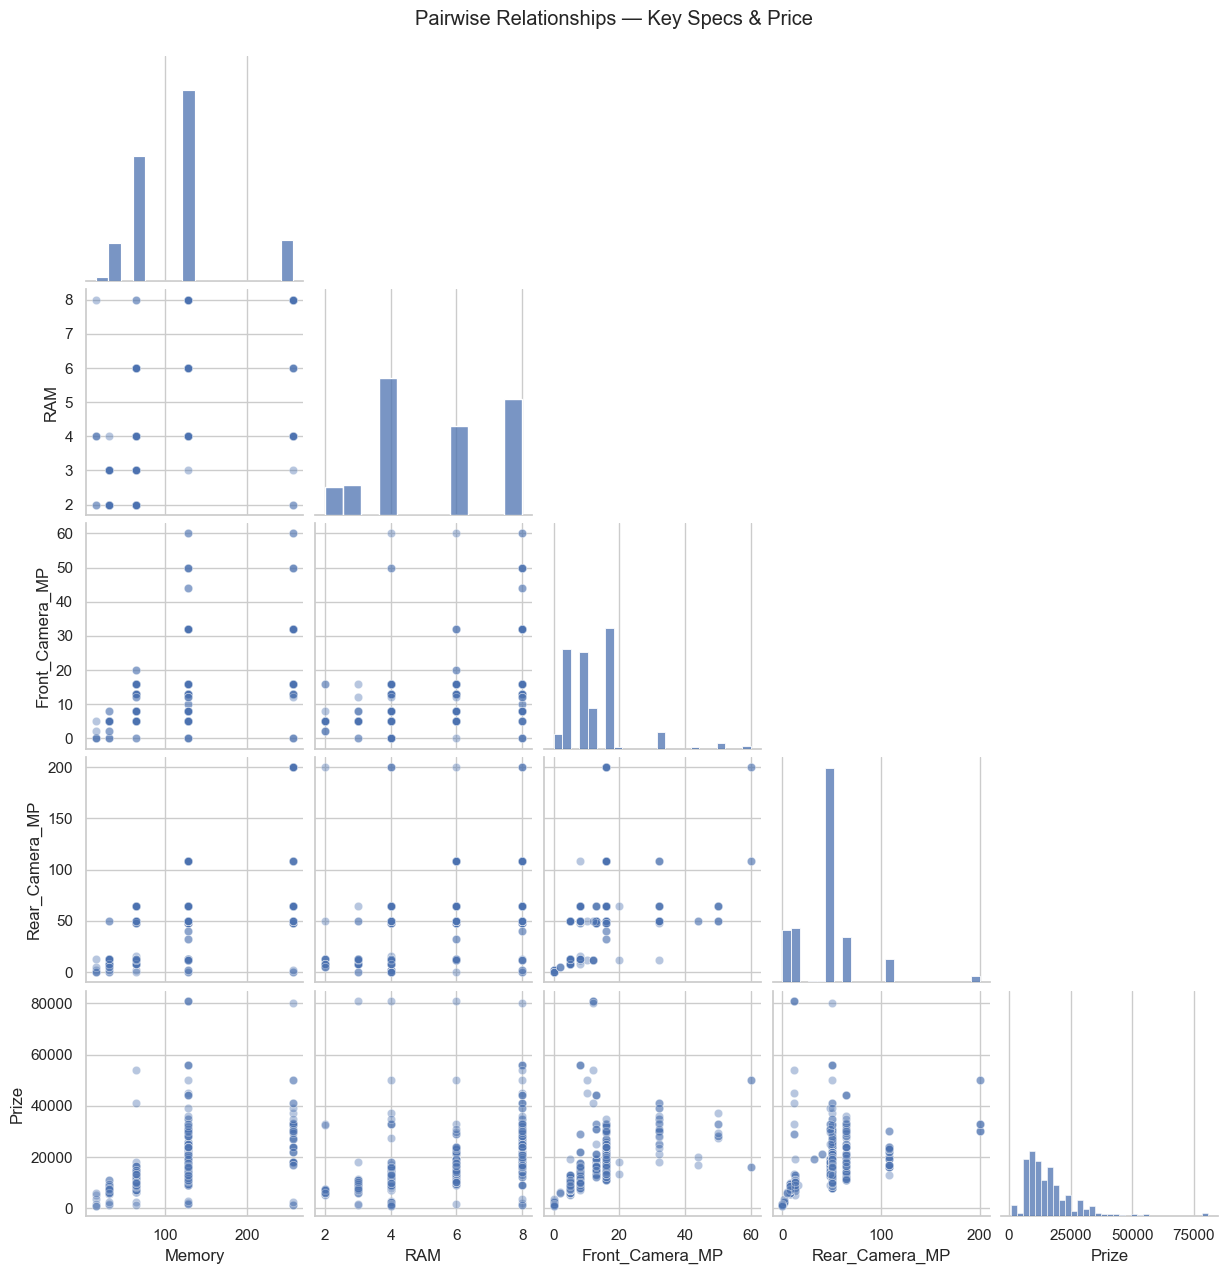

In [29]:
pairplot_cols = ["Memory", "RAM", "Front_Camera_MP", "Rear_Camera_MP", "Prize"]
sns.pairplot(df[pairplot_cols], corner=True, plot_kws={"alpha": 0.4})
plt.suptitle("Pairwise Relationships — Key Specs & Price", y=1.02)
plt.show()

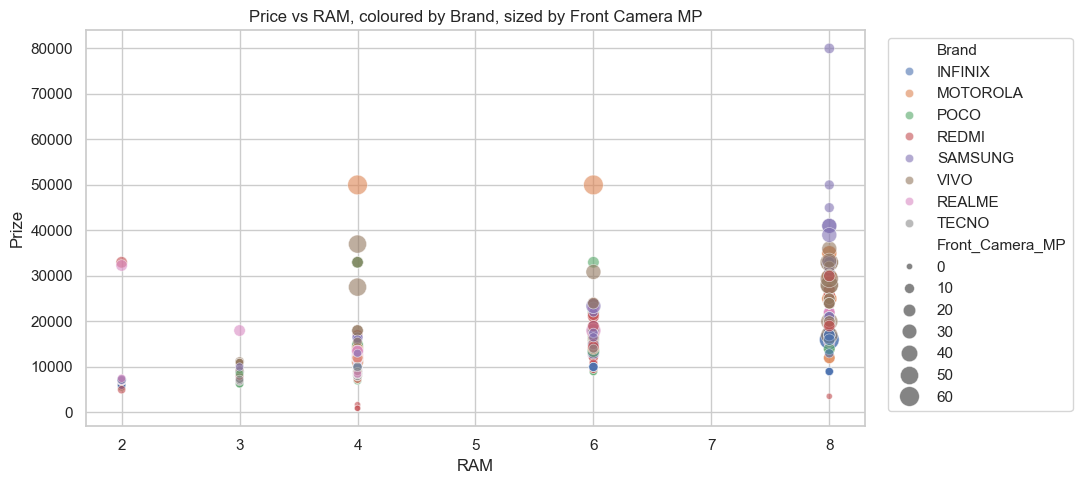

In [30]:
top_brands = df["Brand"].value_counts().head(8).index
subset = df[df["Brand"].isin(top_brands)]

plt.figure(figsize=(11, 5))
sns.scatterplot(data=subset, x="RAM", y="Prize", hue="Brand", size="Front_Camera_MP",
                 sizes=(20, 200), alpha=0.6)
plt.title("Price vs RAM, coloured by Brand, sized by Front Camera MP")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Layering brand and camera resolution onto the RAM–price relationship shows a preview of what the models later confirm: for the **same RAM tier**, Apple/Google/Samsung devices sit at visibly higher prices than budget brands, and larger markers (higher front camera MP) skew toward the upper end of each brand's price band.

In [31]:
print("Top 5 most expensive phones:")
print(df.sort_values("Prize", ascending=False)[["Model", "Brand", "Memory", "RAM", "Prize"]].head(5).to_string(index=False))
print()
print("Top 5 cheapest phones:")
print(df.sort_values("Prize")[["Model", "Brand", "Memory", "RAM", "Prize"]].head(5).to_string(index=False))

Top 5 most expensive phones:
                Model   Brand  Memory  RAM  Prize
 APPLE iPhone 14 Plus   APPLE     128    3  80999
 APPLE iPhone 14 Plus   APPLE     128    6  80999
 APPLE iPhone 14 Plus   APPLE     128    4  80999
SAMSUNG Galaxy S23 5G SAMSUNG     256    8  79999
       Google Pixel 7  GOOGLE     128    8  55999

Top 5 cheapest phones:
     Model    Brand  Memory  RAM  Prize
 redmi min    REDMI      16    4    920
 redmi min    REDMI      16    4    920
  micromax MICROMAX      64    4   1199
micromax 1 MICROMAX     256    8   1299
micromax 2 MICROMAX     256    8   1299


### Summary of EDA findings:
price is right-skewed and dominated by a large budget/mid-range cluster; storage, RAM, and camera MP show clear positive relationships with price while battery and height barely move it on their own; AI lens and premium brands (Apple/Google/Samsung) mark out a higher-priced segment. These patterns directly motivate the preprocessing and modeling choices in the sections that follow.

## 4. Data Preprocessing

With the data explored, finish preparing it for modeling:

- **Price outliers** — checked with the IQR method, but kept (see below), since they represent genuine flagship phones rather than data errors.
- **`Mobile Height`** — one clear data-entry error was found (`MOTOROLA G62 5G` listed at 41.94 cm vs. its duplicate row at what should be ~16.94 cm) and is corrected.
- **`Colour`** — 275 unique values across 541 rows (essentially unique per listing). Too sparse to encode meaningfully, and EDA gave no reason to think colour drives price, so it is dropped, along with the now-redundant raw `Model`, `Rear Camera`, `Front Camera`, and `Processor_` text columns.

In [32]:
# Outlier check on Price using the IQR method
Q1, Q3 = df["Prize"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
price_outliers = df[(df["Prize"] < lower) | (df["Prize"] > upper)]
print(f"{len(price_outliers)} rows flagged as price outliers (bounds: {lower:.0f} to {upper:.0f})")
price_outliers[["Model", "Prize"]].sort_values("Prize").tail(10)

25 rows flagged as price outliers (bounds: -5695 to 34265)


,Model,Prize
489,MOTOROLA Edge 30 Ultra,49999
222,SAMSUNG Galaxy S22 Plus 5G,49999
532,APPLE iPhone 12,53999
426,Google Pixel 7,55999
417,Google Pixel 7,55999
416,Google Pixel 7,55999
536,SAMSUNG Galaxy S23 5G,79999
493,APPLE iPhone 14 Plus,80999
520,APPLE iPhone 14 Plus,80999
525,APPLE iPhone 14 Plus,80999


These "outliers" are all genuine flagship/premium phones (iPhones, Galaxy S23, Pixel 7, etc.) rather than data errors, so they are **kept** in the dataset — a good price-prediction model needs to learn the premium segment too.

In [33]:
# Fix one identified data-entry error: MOTOROLA G62 5G height should be ~16.94cm, not 41.94cm
df.loc[(df["Model"] == "MOTOROLA G62 5G") & (df["Mobile Height"] == 41.94), "Mobile Height"] = 16.94

# Drop raw text columns now that engineered equivalents exist; drop high-cardinality Colour
model_df = df.drop(columns=["Model", "Colour", "Rear Camera", "Front Camera", "Processor_"])
model_df.head()

,Memory,RAM,Battery_,AI Lens,Mobile Height,Prize,Brand,Rear_Camera_MP,Front_Camera_MP,Processor_Family
0,64,4,6000,1,16.76,7299,INFINIX,13.0,5.0,Unisoc
1,64,4,6000,1,16.76,7299,INFINIX,13.0,5.0,Unisoc
2,128,8,5000,0,16.64,11999,MOTOROLA,50.0,16.0,Snapdragon
3,32,2,5000,0,16.56,5649,POCO,8.0,5.0,Helio
4,128,8,5000,1,16.76,8999,INFINIX,50.0,5.0,Helio


## 5. Feature Extraction

Quantify how strongly each numeric feature correlates with price, to complement the visual patterns already seen in the EDA.

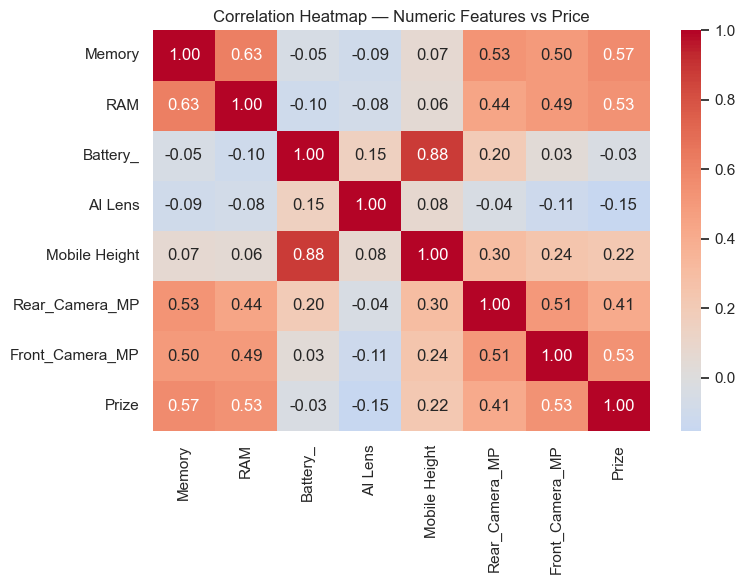

In [54]:
corr_cols = ["Memory", "RAM", "Battery_", "AI Lens", "Mobile Height",
             "Rear_Camera_MP", "Front_Camera_MP", "Prize"]
corr = model_df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Numeric Features vs Price")
plt.tight_layout()
plt.show()

In [35]:
corr["Prize"].sort_values(ascending=False)

Prize              1.000000
Memory             0.566660
Front_Camera_MP    0.532321
RAM                0.532024
Rear_Camera_MP     0.410367
Mobile Height      0.222297
Battery_          -0.034297
AI Lens           -0.153691
Name: Prize, dtype: float64

**Correlation with price (highest to lowest):** Memory (storage), Front Camera MP, RAM, and Rear Camera MP show the strongest positive correlation with price — matching what the EDA scatterplots suggested. Mobile Height has a weak positive relationship. Battery capacity and AI Lens show essentially no linear correlation with price on their own — but that doesn't rule out non-linear importance, which is why we also compute model-based feature importance later.

### 5.1 Label Encoding — Categorical Features

`Brand` and `Processor_Family` are text categories. Instead of one-hot encoding (which was used previously), apply **Label Encoding** to convert each category to an integer code. This keeps the feature matrix compact and works well with the tree-based models used here (Decision Tree, Random Forest), which split on thresholds rather than assuming a linear ordering between codes.

In [57]:
from sklearn.preprocessing import LabelEncoder

le_brand = LabelEncoder()
le_processor = LabelEncoder()

if "Brand" in model_df.columns:
    model_df["Brand_Encoded"] = le_brand.fit_transform(model_df["Brand"])
    model_df["Processor_Family_Encoded"] = le_processor.fit_transform(model_df["Processor_Family"])
    model_df = model_df.drop(columns=["Brand", "Processor_Family"])

model_df.head()


,Memory,RAM,Battery_,AI Lens,Mobile Height,Prize,Rear_Camera_MP,Front_Camera_MP,Brand_GOOGLE,Brand_IKALL,Brand_INFINIX,Brand_IQOO,Brand_ITEL,Brand_LAVA,Brand_MICROMAX,Brand_MOTOROLA,Brand_NOKIA,Brand_NOTHING,Brand_ONEPLUS,Brand_OPPO,Brand_POCO,Brand_REALME,Brand_REDMI,Brand_SAMSUNG,Brand_TECNO,Brand_VIVO,Processor_Family_Exynos,Processor_Family_Google_Tensor,Processor_Family_Helio,Processor_Family_Other,Processor_Family_Snapdragon,Processor_Family_Unisoc
0,64,4,6000,1,16.76,7299,13.0,5.0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,64,4,6000,1,16.76,7299,13.0,5.0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,128,8,5000,0,16.64,11999,50.0,16.0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,32,2,5000,0,16.56,5649,8.0,5.0,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
4,128,8,5000,1,16.76,8999,50.0,5.0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


### 5.2 Standardization — Numeric Features

Standardization rescales each numeric feature to have **mean 0 and standard deviation 1** (`(x - mean) / std`). This matters because features here sit on very different scales — e.g. `Battery_` is in the thousands (mAh) while `AI Lens` is 0/1 — which can distort distance- or coefficient-based models like Linear Regression if left unscaled.

In [60]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ["Memory", "RAM", "Battery_", "Mobile Height", "Rear_Camera_MP", "Front_Camera_MP"]

scaler_standard = StandardScaler()
standardized_features = pd.DataFrame(
    scaler_standard.fit_transform(model_df[numeric_cols]),
    columns=[f"{col}_Standardized" for col in numeric_cols],
    index=model_df.index
)
standardized_features.describe().T

,count,mean,std,min,25%,50%,75%,max
Memory_Standardized,541.0,-3.283469e-17,1.000925,-1.561671,-0.768868,0.288203,0.288203,2.402345
RAM_Standardized,541.0,0.000000e+00,1.000925,-1.713193,-0.704665,0.303863,1.312392,1.312392
Battery__Standardized,541.0,-5.549063e-16,1.000925,-5.223818,0.164752,0.164752,0.164752,2.730738
Mobile Height_Standardized,541.0,-9.062375e-16,1.000925,-5.961703,0.086222,0.186937,0.302759,0.660296
Rear_Camera_MP_Standardized,541.0,5.253551e-17,1.000925,-1.476422,-1.060176,0.124525,0.124525,4.927366
Front_Camera_MP_Standardized,541.0,-6.566938e-17,1.000925,-1.325828,-0.773059,-0.441398,0.443032,5.307397


### 5.3 Normalization — Numeric Features

Normalization (Min-Max scaling) rescales each numeric feature to a fixed **0–1 range** (`(x - min) / (max - min)`), rather than centering around a mean. Shown here for comparison alongside standardization.

In [61]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
normalized_features = pd.DataFrame(
    scaler_minmax.fit_transform(model_df[numeric_cols]),
    columns=[f"{col}_Normalized" for col in numeric_cols],
    index=model_df.index
)
normalized_features.describe().T

,count,mean,std,min,25%,50%,75%,max
Memory_Normalized,541.0,0.393962,0.252503,0.0,0.200000,0.466667,0.466667,1.0
RAM_Normalized,541.0,0.566235,0.330820,0.0,0.333333,0.666667,1.000000,1.0
Battery__Normalized,541.0,0.656708,0.125830,0.0,0.677419,0.677419,0.677419,1.0
Mobile Height_Normalized,541.0,0.900287,0.151152,0.0,0.913308,0.928517,0.946008,1.0
Rear_Camera_MP_Normalized,541.0,0.230555,0.156302,0.0,0.065000,0.250000,0.250000,1.0
Front_Camera_MP_Normalized,541.0,0.199877,0.150896,0.0,0.083333,0.133333,0.266667,1.0


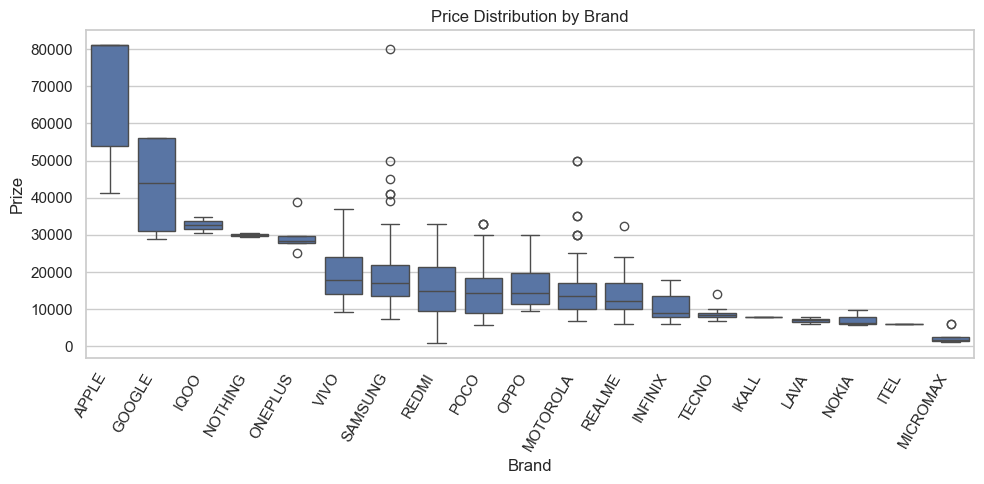

In [36]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Brand", y="Prize", order=df.groupby("Brand")["Prize"].median().sort_values(ascending=False).index)
plt.xticks(rotation=60, ha="right")
plt.title("Price Distribution by Brand")
plt.tight_layout()
plt.show()

Brand clearly matters too: Apple and Google command far higher median prices than budget brands like micromax/itel/Lava — this is why Brand is included as a categorical feature.

## 6. Model Building & Training
### Summary:
**What we do:**
1. Train Linear Regression model
2. Train Decision Tree Regressor
3. Train Random Forest Regressor
**Why it matters:**
- Test different algorithms to find best fit
- Compare simple vs complex models
- Leverage ensemble methods for better predictions

Split the data into training (80%) and testing (20%) sets, then train four regression models of increasing complexity, as suggested in the project brief.

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (432, 31)  Test: (109, 31)


In [65]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42),
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
print("All 3 models trained.")

All 3 models trained.


## 7. Model Evaluation

Compare all 3 models using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² on the held-out test set.

In [66]:
rows = []
for name, model in trained.items():
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    rows.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,Random Forest,1598.097624,4091.872723,0.878519
1,Decision Tree,2188.549663,4760.437926,0.835579
2,Linear Regression,2729.703542,5862.010933,0.750680


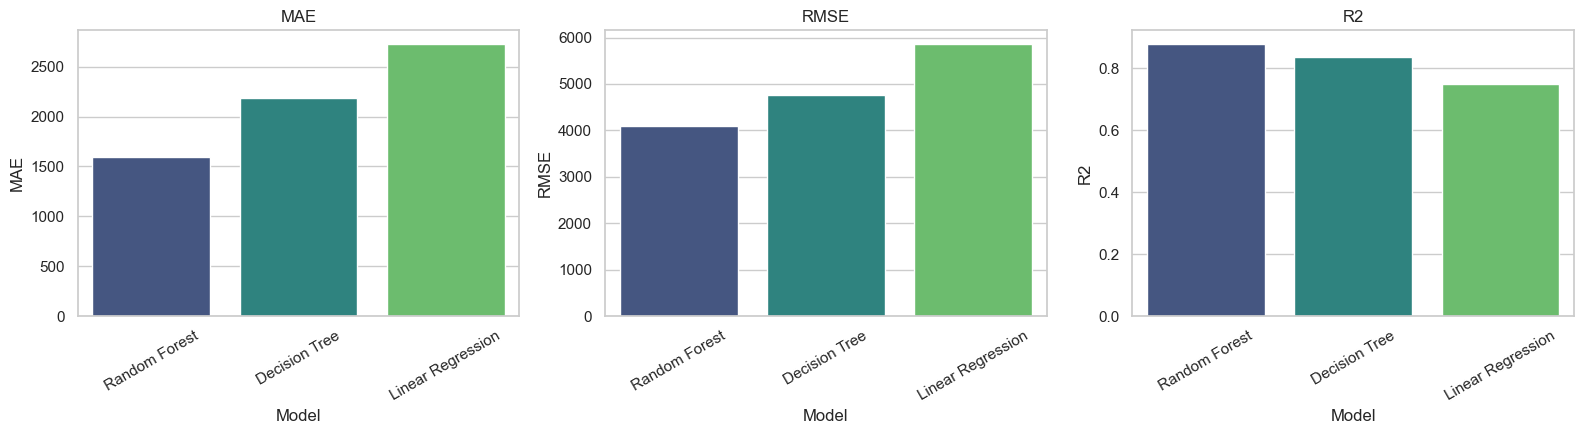

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    sns.barplot(
        data=results_df,
        x="Model",
        y=metric,
        hue="Model",
        palette="viridis",
        legend=False,
        ax=ax
    )
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Random Forest** gives the best overall performance — the lowest MAE and RMSE and the highest R² — meaning its predictions are, on average, closest to actual prices and it explains the most variance in price. It comfortably outperforms a single Decision Tree and plain Linear Regression, which struggles because price does not vary linearly with specs (e.g. the jump from mid-range to flagship phones).

## 8. Feature Importance Analysis

Use the best-performing model (Random Forest) to rank which features actually drove its predictions.

In [67]:
rf_importance = pd.Series(trained["Random Forest"].feature_importances_, index=X.columns).sort_values(ascending=False)

importance_df = pd.DataFrame({
    "Random Forest": rf_importance
}).fillna(0).sort_values("Random Forest", ascending=False)

importance_df.head(15)


,Random Forest
Front_Camera_MP,0.481458
Brand_GOOGLE,0.108961
Battery_,0.090581
Memory,0.084502
RAM,0.076887
Rear_Camera_MP,0.049142
Mobile Height,0.040907
Brand_SAMSUNG,0.012852
Processor_Family_Helio,0.008515
Processor_Family_Google_Tensor,0.007111


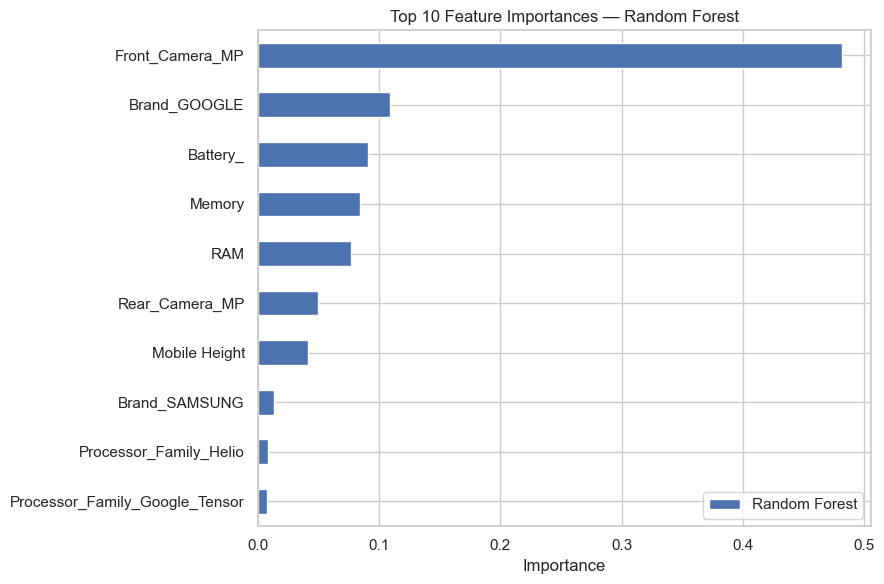

In [68]:
top_features = importance_df.head(10)
top_features.plot(kind="barh", figsize=(9, 6))
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


**Random Forest highlights these as the top drivers of mobile phone price:**

1. **Front Camera (MP)** — by far the strongest predictor.
2. **Internal Memory (storage)**
3. **RAM**
4. **Battery capacity**
5. **Rear Camera (MP)**
6. **Brand** (particularly Google and Samsung, which carry a premium)
7. **Mobile Height** (a weak proxy for screen size/form factor)

This is consistent with the correlation analysis and EDA scatterplots earlier — Memory, RAM, and camera specs stood out there too — but the model also surfaces **Battery capacity** and **Brand** as important, which the simple linear correlation missed because their relationship with price is non-linear/segment-specific rather than a straight line.

## 9. Recommendations:

Based on the EDA, feature extraction, and model results:

1. **Pricing should be anchored primarily on storage (Memory), RAM, and front camera resolution** — these three specs are the strongest, most consistent price drivers across every method used (EDA, correlation, Random Forest). Any pricing strategy or competitor-benchmarking exercise should prioritize these specs.
2. **Camera specs are a strong marketing lever.** Front camera megapixels showed the single highest importance in the Random Forest model — likely reflecting how heavily camera quality is marketed and how much buyers are willing to pay for it. Highlighting front/rear camera MP prominently in listings and ads is likely to justify premium pricing.
3. **Battery capacity matters more than its raw correlation suggests.** It showed almost no linear correlation with price but ranked in the top 5 for the Random Forest model — the EDA shows why: most phones cluster at a fixed 5,000mAh regardless of price tier, so the effect is threshold-based rather than linear. Consider using battery capacity as a segment/tier marker rather than a continuously-priced spec.
4. **Brand carries a real premium independent of specs** — Google and Samsung devices command higher prices even after accounting for hardware specs, reflecting brand equity, software support, and ecosystem value. This premium should be factored explicitly into competitive pricing rather than relying on spec-based pricing alone.
5. **Colour and processor sub-model have limited standalone pricing power** — Colour was dropped for being too sparse to model reliably, and specific processor identity mattered far less than expected once families were grouped, so pricing strategy should not weight these heavily.
6. **Recommended model for production use: Random Forest** (MAE ≈ ₹1,600, R² ≈ 0.88 on held-out data) — it is the most accurate of the three while remaining reasonably interpretable via feature importances, striking a good balance for a pricing-support tool the business can trust and explain.

## Conclusion

Storage, RAM, and camera specifications are the clearest, most defensible drivers of mobile phone pricing in this dataset, with brand contributing a meaningful premium on top of specs. A Random Forest model trained on these engineered features predicts price with an average error of roughly ₹1,600–1,700 (R² ≈ 0.88), making it a solid foundation for a data-driven pricing strategy tool.